<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

### Random Forest Classification — Required Steps

**Overall workflow:**

`Explore → Prepare X/y → Preprocess → Split → Pipeline → Random Forest → Train → Predict → Evaluate → Conclusion`


1. **Import the required libraries**

   * Pandas
   * Visualization libraries
   * Scikit-learn preprocessing, pipeline, Random Forest, and evaluation tools

In [1]:
# Import required modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ML libraries
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report,mean_squared_error,mean_absolute_error,r2_score,confusion_matrix
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

# Start coding!

2. **Load the `car_insurance.csv` dataset**

   * Display the first few rows.

In [2]:
df = pd.read_csv('car_insurance.csv')

In [3]:
df.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


3. **Explore the dataset**

   * Check `shape`, `info()`, and `describe()`.
   * Check for missing values.
   * Identify numerical and categorical columns.
   * Visualize the `outcome` target distribution.

In [4]:
print(df.shape)
print(df.info())

(10000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  duis                 1000

In [5]:
df.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [6]:
df.isnull().sum()

id                       0
age                      0
gender                   0
driving_experience       0
education                0
income                   0
credit_score           982
vehicle_ownership        0
vehicle_year             0
married                  0
children                 0
postal_code              0
annual_mileage         957
vehicle_type             0
speeding_violations      0
duis                     0
past_accidents           0
outcome                  0
dtype: int64

In [7]:
df['credit_score'].isnull().mean() * 100

np.float64(9.82)

In [8]:
df['annual_mileage'].isnull().mean() * 100 # Will keep both rows because missing value percentage is low

np.float64(9.569999999999999)

In [9]:
print('Credit Score')
print("Mean:  ", df['credit_score'].mean())
print("Median:", df['credit_score'].median())
print('Annual Mileage')
print("Mean:  ", df['annual_mileage'].mean())
print("Median:", df['annual_mileage'].median())

Credit Score
Mean:   0.515812809602791
Median: 0.5250327586154788
Annual Mileage
Mean:   11697.003206900365
Median: 12000.0


In [10]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
df[['credit_score', 'annual_mileage']] = imputer.fit_transform(df[['credit_score', 'annual_mileage']])

In [11]:
df['credit_score'].isnull().sum()

np.int64(0)

In [12]:
df['annual_mileage'].isnull().sum()

np.int64(0)

In [13]:
df.dtypes

id                       int64
age                      int64
gender                   int64
driving_experience      object
education               object
income                  object
credit_score           float64
vehicle_ownership      float64
vehicle_year            object
married                float64
children               float64
postal_code              int64
annual_mileage         float64
vehicle_type            object
speeding_violations      int64
duis                     int64
past_accidents           int64
outcome                float64
dtype: object

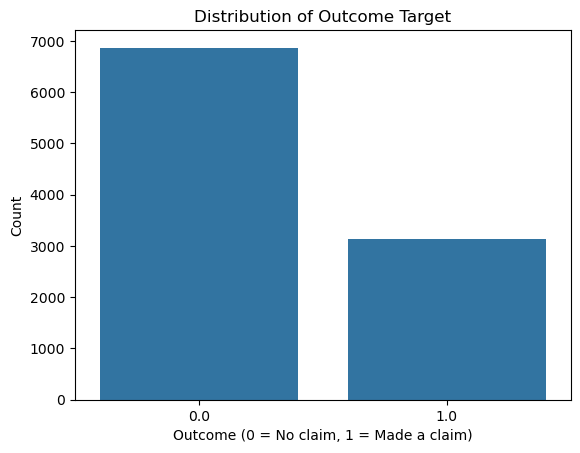

In [14]:
sns.countplot(df, x='outcome')
plt.title('Distribution of Outcome Target')
plt.xlabel('Outcome (0 = No claim, 1 = Made a claim)')
plt.ylabel('Count')
plt.show()

4. **Prepare features and target**

   * Create `X` containing the input features.
   * Create `y` containing `outcome`.
   * Decide whether the `id` column should be removed.

In [15]:
X = df.drop(columns=['id', 'outcome', 'postal_code'])
y = df['outcome']

5. **Identify feature types**

   * Numerical
   * Categorical
   * Ordinal, where appropriate

In [17]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

6. **Preprocess the features**

   * Apply suitable encoding/transformation.
   * Organize preprocessing using `ColumnTransformer`.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, RobustScaler

In [21]:
num_trans = Pipeline(steps=[
    ('scaler', RobustScaler())
])
num_trans

,steps,"[('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [22]:
cat_trans = Pipeline(steps=[
    ('ode', OrdinalEncoder())
])

cat_trans

,steps,"[('ode', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [26]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_trans, num_cols),
        ('cat', cat_trans, cat_cols)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


7. **Split the data**

   * 80% training data.
   * 20% testing data.
   * Use `random_state`.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

8. **Create a machine learning `Pipeline`**

   * Combine the `ColumnTransformer` preprocessing with `RandomForestClassifier`.

In [29]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestClassifier())
])
full_pipeline

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


9. **Train the Random Forest**

   * Fit the pipeline using `X_train` and `y_train`.

In [30]:
full_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


10. **Make predictions**

    * Predict `X_test`.
    * Store the result as `y_pred`.

In [32]:
y_pred = full_pipeline.predict(X_test)

11. **Evaluate the model**

    * Accuracy
    * Confusion Matrix
    * Precision
    * Recall
    * F1-score
    * Classification Report

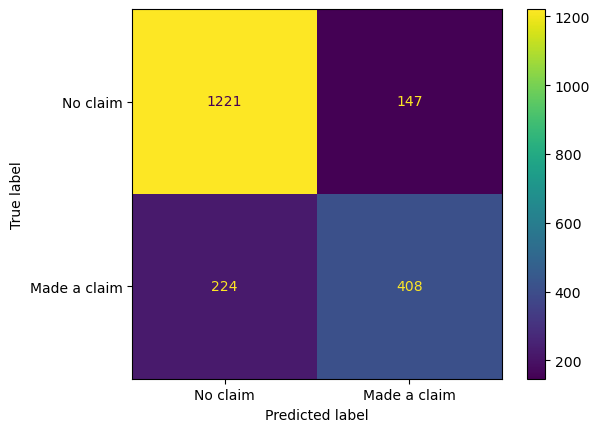

In [37]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No claim', 'Made a claim'])
disp.plot()
plt.show()

In [38]:
df['outcome'].value_counts()

outcome
0.0    6867
1.0    3133
Name: count, dtype: int64

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1368
         1.0       0.74      0.65      0.69       632

    accuracy                           0.81      2000
   macro avg       0.79      0.77      0.78      2000
weighted avg       0.81      0.81      0.81      2000



- ROC and AUC

In [39]:
from sklearn.metrics import roc_curve, auc

In [42]:
y_prob = full_pipeline.predict_proba(X_test)[:,1]

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

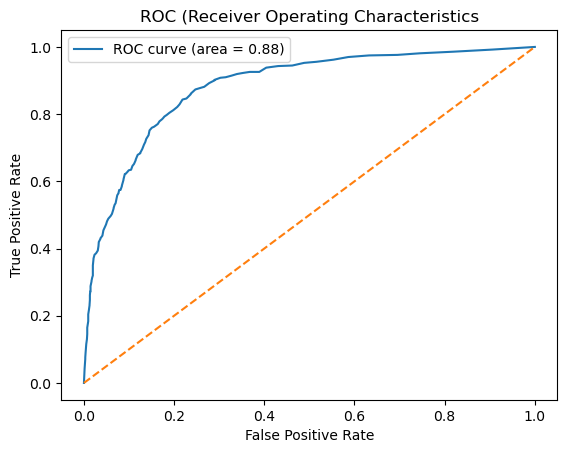

In [46]:
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC (Receiver Operating Characteristics')
plt.legend()
plt.savefig('roc.png')
plt.show()

12. **Write a conclusion**

    * Explain the preprocessing performed.
    * State the model's performance.
    * Interpret the evaluation metrics.
    * Conclude how well the Random Forest predicts insurance claims.


1. Explain the preprocessing performed.
    - Filled missing values (in credit_score and annual_mileage, both around 10%) with the mean value using SimpleImputer.
    - Scaled number columns using RobustScaler.
    - Turned category columns into numbers using OrdinalEncoder.
    - Split data into 80% for training, 20% for testing with train_test_split.

2. State the model's performance.
    - Accuracy: 81% - it got the right answer 81 out of 100 times.
    - ROC AUC: 0.88 - a strong score (1.0 = perfect, 0.5 = random guessing).

3. Interpret the evaluation metrics.
    - The model is good at spotting "no claim" customers (89% recall - catches most of them).
    - The model is weaker at spotting "made a claim" customers (65% recall- misses about 1 in 3 real claims).
    - This means the model plays it safe: it correctly flags most non-risky clients, but lets some risky ones slip through.
4. Conclude how well the Random Forest predicts insurance claims.
    - The Random Forest model does a decent job overall (81% accuracy, strong AUC), but it's better at confirming who won't claim than catching who will claim.